In [22]:
import os
os.environ["CUDA_VISIBLE_DEVICES"] = "0"
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "2"
os.environ['PATH'] += ':/tools/Xilinx/Vivado/2023.2/bin'
os.environ['PATH'] += ':/tools/Xilinx/Vitis_HLS/2023.2/bin'

os.environ["TF_USE_LEGACY_KERAS"] = "1"

import h5py
import numpy as np
import tensorflow as tf
import qkeras
import hls4ml

print("TensorFlow Version:", tf.__version__)
print("hls4ml Version    :", hls4ml.__version__)
print("GPUs Available    :", tf.config.list_physical_devices('GPU'))

TensorFlow Version: 2.15.1
hls4ml Version    : 1.3.0
GPUs Available    : [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [23]:
import h5py
import numpy as np
import gc

def load_and_filter_2gb_budget(h5_path, x_key, y_key, min_hits=5, chunk_size=2000):
    x_chunks = []
    y_chunks = []
    
    with h5py.File(h5_path, 'r') as f:
        y_raw = f[y_key][:].flatten()
        total_samples = len(y_raw)
        x_ds = f[x_key]
        
        for i in range(0, total_samples, chunk_size):
            x_chunk = x_ds[i : i + chunk_size]
            y_chunk = y_raw[i : i + chunk_size]
            
            n_hits = np.count_nonzero(x_chunk, axis=(1, 2))
            mask = (y_chunk == 0) | ((y_chunk == 1) & (n_hits >= min_hits))
            
            if np.any(mask):
                x_chunks.append(x_chunk[mask].astype(np.uint8))
                y_chunks.append(y_chunk[mask].astype(np.uint8))
            
            del x_chunk, y_chunk, n_hits, mask
            
    X_filtered = np.expand_dims(np.concatenate(x_chunks, axis=0), -1)
    y_filtered = np.concatenate(y_chunks, axis=0)
    
    del x_chunks, y_chunks
    gc.collect()
    
    return X_filtered, y_filtered

In [24]:
X_train, y_train = load_and_filter_2gb_budget('processed_physics_data.h5', 'X_train', 'y_train', min_hits=5)
X_val, y_val = load_and_filter_2gb_budget('processed_physics_data.h5', 'X_val', 'y_val', min_hits=5)

print(f"\n Filtered Training size: {X_train.shape}")
print(f"Filtered Validation size: {X_val.shape}")


 Filtered Training size: (83850, 24, 36, 1)
Filtered Validation size: (20955, 24, 36, 1)


In [25]:
from tensorflow.keras.layers import Input, BatchNormalization, MaxPooling2D, Flatten, Dropout
from tensorflow.keras.models import Model
from qkeras import QConv2D, QActivation, QDense, quantized_bits

W_Q = quantized_bits(16, 6, alpha=1)
A_Q = "quantized_relu(16,6)"

inputs = Input(shape=(24, 36, 1), name='input_layer')
x = QConv2D(12, kernel_size=(3, 3), padding="same", kernel_quantizer=W_Q, use_bias=False, name='qconv_1')(inputs)
x = BatchNormalization(name='batch_normalization')(x)
x = QActivation(A_Q, name='qact_1')(x)
x = MaxPooling2D(pool_size=(2, 2), name='max_pooling2d')(x)

x = QConv2D(24, kernel_size=(3, 3), padding="same", kernel_quantizer=W_Q, use_bias=False, name='qconv_2')(x)
x = BatchNormalization(name='batch_normalization_1')(x)
x = QActivation(A_Q, name='qact_2')(x)
x = MaxPooling2D(pool_size=(2, 2), name='max_pooling2d_1')(x)

x = Flatten(name='flatten')(x)
x = QDense(12, kernel_quantizer=W_Q, use_bias=False, name='qdense_1')(x)
x = BatchNormalization(name='batch_normalization_2')(x)
x = QActivation(A_Q, name='qact_3')(x)
x = Dropout(0.2, name='dropout')(x)

outputs = QDense(1, activation="sigmoid", kernel_quantizer=W_Q, use_bias=False, name='qoutput')(x)

model = Model(inputs=inputs, outputs=outputs, name="Optimized_AUC_Micro_QNet")
model.summary()

Model: "Optimized_AUC_Micro_QNet"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 24, 36, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ qconv_1 (QConv2D)               │ (None, 24, 36, 12)     │           108 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 24, 36, 12)     │            48 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ qact_1 (QActivation)            │ (None, 24, 36, 12)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 12, 18, 12)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ qconv_2 (QConv2D)               │ (None, 12, 18, 24)     │         2,592 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 12, 18, 24)     │            96 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ qact_2 (QActivation)            │ (None, 12, 18, 24)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 6, 9, 24)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1296)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ qdense_1 (QDense)               │ (None, 12)             │        15,552 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 12)             │            48 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ qact_3 (QActivation)            │ (None, 12)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 12)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ qoutput (QDense)                │ (None, 1)              │            12 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 18,456 (72.09 KB)

 Trainable params: 18,360 (71.72 KB)

 Non-trainable params: 96 (384.00 B)

In [26]:
model.load_weights("best_model.keras")

In [27]:
import h5py

with h5py.File("temp_weights.h5", "r") as f:
    layers = f["layers"]
    ordered_weights = [
        layers["q_conv2d/vars/0"][()],
        layers["batch_normalization/vars/0"][()],
        layers["batch_normalization/vars/1"][()],
        layers["batch_normalization/vars/2"][()],
        layers["batch_normalization/vars/3"][()],
        layers["q_conv2d_1/vars/0"][()],
        layers["batch_normalization_1/vars/0"][()],
        layers["batch_normalization_1/vars/1"][()],
        layers["batch_normalization_1/vars/2"][()],
        layers["batch_normalization_1/vars/3"][()],
        layers["q_dense/vars/0"][()],
        layers["batch_normalization_2/vars/0"][()],
        layers["batch_normalization_2/vars/1"][()],
        layers["batch_normalization_2/vars/2"][()],
        layers["batch_normalization_2/vars/3"][()],
        layers["q_dense_1/vars/0"][()],
    ]
model.set_weights(ordered_weights)

# Pruning


In [28]:
import qkeras
trainable_layers = [
    layer for layer in model.layers 
    if isinstance(layer, (qkeras.QConv2D, qkeras.QDense, tf.keras.layers.Conv2D, tf.keras.layers.Dense))
]

print(f"Targeting {len(trainable_layers)} quantized layers for pruning.")

Targeting 4 quantized layers for pruning.


In [29]:
import numpy as np

target_sparsity = 10

for layer in trainable_layers:
    weights = layer.get_weights()
    if not weights:
        continue
    
    kernel = weights[0]
    threshold = np.percentile(np.abs(kernel), target_sparsity)
    mask = np.abs(kernel) >= threshold
    pruned_kernel = kernel * mask
    
    weights[0] = pruned_kernel
    layer.set_weights(weights)

print(f"Success! {target_sparsity}% of the weights in all QConv2D and QDense layers have been zeroed out.")

Success! 10% of the weights in all QConv2D and QDense layers have been zeroed out.


In [30]:
total_weights = 0
zero_weights = 0

for layer in trainable_layers:
    weights = layer.get_weights()
    if weights:
        kernel = weights[0]
        total_weights += kernel.size
        zero_weights += np.sum(kernel == 0)

sparsity = (zero_weights / total_weights) * 100
print(f"Total parameters checked: {total_weights:,}")
print(f"Zeroed-out parameters   : {zero_weights:,}")
print(f"Overall Sparsity        : {sparsity:.2f}% (Target was {target_sparsity:.2f}%)")

Total parameters checked: 18,264
Zeroed-out parameters   : 1,829
Overall Sparsity        : 10.01% (Target was 10.00%)


In [31]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
    loss='binary_crossentropy',
    metrics=['accuracy', tf.keras.metrics.AUC(name='auc')]
)

pruned_save_path = "best_model_pruned_10pct.keras"
model.save(pruned_save_path)
print(f"Success! Pruned model saved to: {pruned_save_path}")

Success! Pruned model saved to: best_model_pruned_10pct.keras


In [32]:
from sklearn.metrics import roc_auc_score
import numpy as np
import tensorflow as tf
tf.config.run_functions_eagerly(True)
with tf.device('/CPU:0'):
    y_pred = model.predict(X_val, batch_size=256).ravel()

y_true = y_val.ravel()
pruned_auc = roc_auc_score(y_true, y_pred)
pruned_acc = np.mean((y_pred >= 0.5).astype(int) == y_true) * 100

print(f"Pruned Model Accuracy : {pruned_acc:.2f}%")
print(f"Pruned Model AUC      : {pruned_auc:.4f}")

/opt/conda/envs/hls4ml/lib/python3.10/site-packages/tensorflow/python/data/ops/structured_function.py:258: UserWarning: Even though the `tf.config.experimental_run_functions_eagerly` option is set, this option does not apply to tf.data functions. To force eager execution of tf.data functions, please use `tf.data.experimental.enable_debug_mode()`.
  warnings.warn(


82/82 ━━━━━━━━━━━━━━━━━━━━ 3s 26ms/step
Pruned Model Accuracy : 95.94%
Pruned Model AUC      : 0.9685



# HLS4ML config


In [42]:
import tf_keras as keras
import qkeras
import hls4ml
import json

print("Model ready:", model.name)

Model ready: Optimized_AUC_Micro_QNet


In [43]:
import keras as k3


k3.__version__ = '2.15.0'

print("Configured hls4ml parsing mode.")

Configured hls4ml parsing mode.


In [44]:
import json
import hls4ml
import tf_keras as keras
unpatched_to_json = keras.Model.to_json
def _fixed_to_json(*args, **kwargs):
    raw_json = unpatched_to_json(model, **kwargs)
    arch = json.loads(raw_json)
    inps = arch["config"].get("input_layers", [])
    if inps and isinstance(inps[0], str):
        arch["config"]["input_layers"] = [[inps[0], inps[1], inps[2]]]

    outs = arch["config"].get("output_layers", [])
    if outs and isinstance(outs[0], str):
        arch["config"]["output_layers"] = [[outs[0], outs[1], outs[2]]]

    layers = arch["config"].get("layers", [])
    for i, layer in enumerate(layers):
        cfg = layer.get("config", {})
        if "batch_shape" in cfg:
            cfg["batch_input_shape"] = cfg.pop("batch_shape")

        if layer.get("class_name") == "InputLayer":
            layer["inbound_nodes"] = []
            continue

        ib = layer.get("inbound_nodes", [])
        if isinstance(ib, list) and len(ib) > 0 and isinstance(ib[0], dict):
            new_nodes = []
            for node_dict in ib:
                conns = []
                for arg in node_dict.get("args", []):
                    if (
                        isinstance(arg, dict)
                        and "config" in arg
                        and "keras_history" in arg["config"]
                    ):
                        kh = arg["config"]["keras_history"]
                        conns.append([kh[0], kh[1], kh[2], {}])
                if conns:
                    new_nodes.append(conns)
            layer["inbound_nodes"] = (
                new_nodes
                if new_nodes
                else (
                    [[[layers[i - 1]["name"], 0, 0, {}]]] if i > 0 else []
                )
            )
        elif not ib:
            layer["inbound_nodes"] = (
                [[[layers[i - 1]["name"], 0, 0, {}]]] if i > 0 else []
            )

    return json.dumps(arch)

In [57]:
import json


# Patch to convert Keras 3 model config -> Keras 2 model config expected by hls4ml
def _fixed_to_json(*args, **kwargs):
    cfg = model.get_config()

    # Format input_layers to Keras 2 style: [['layer_name', 0, 0]]
    if "input_layers" in cfg:
        formatted_inputs = []
        for inp in cfg["input_layers"]:
            if isinstance(inp, str):
                formatted_inputs.append([inp, 0, 0])
            elif isinstance(inp, (list, tuple)):
                formatted_inputs.append(list(inp))
        cfg["input_layers"] = formatted_inputs

    # Format output_layers to Keras 2 style: [['layer_name', 0, 0]]
    if "output_layers" in cfg:
        formatted_outputs = []
        for out in cfg["output_layers"]:
            if isinstance(out, str):
                formatted_outputs.append([out, 0, 0])
            elif isinstance(out, (list, tuple)):
                formatted_outputs.append(list(out))
        cfg["output_layers"] = formatted_outputs

    model_struct = {"class_name": "Functional", "config": cfg}
    return json.dumps(model_struct)


# Attach patch to model
model.to_json = _fixed_to_json
print("✅ Keras 3 to Keras 2 JSON patch applied!")

✅ Keras 3 to Keras 2 JSON patch applied!


In [59]:
import hls4ml

# 1. Generate the initial config dictionary from the model
config = hls4ml.utils.config_from_keras_model(
    model, granularity="name", default_precision="ap_fixed<16,6>"
)

# 2. Modify specific layer Reuse Factors
config["LayerName"]["qdense_1"]["ReuseFactor"] = 256
config["LayerName"]["qconv_2"]["ReuseFactor"] = 16

print("✅ 'config' created and updated successfully!")

IndexError: list index out of range

In [47]:
if not isinstance(config['LayerName']['qdense_1'].get('Precision'), dict):
    config['LayerName']['qdense_1']['Precision'] = {}

config['LayerName']['qdense_1']['Precision']['result'] = 'ap_fixed<16,6>'
config['LayerName']['qdense_1']['Precision']['accum'] = 'ap_fixed<18,8>'

config['LayerName']['qdense_1']['Strategy'] = 'Resource'

NameError: name 'config' is not defined

In [112]:
hls_model_final = hls4ml.converters.convert_from_keras_model(
    model,
    hls_config=config,
    io_type='io_stream',
    backend='Vitis',
    output_dir='my_hls_project/micro_qnet_FINAL',
    part='xcvu080-ffvb2104-2-e'
)

In [113]:
hls_model_final.compile()

# C-Simulation

In [36]:
import numpy as np
import tensorflow as tf

# 1. Cast input to float32 (required by hls4ml C-simulation wrapper)
X_sample = X_val[:1000].astype(np.float32)

# 2. Force Keras prediction onto CPU
with tf.device('/CPU:0'):
    y_keras = model.predict(X_sample)

# 3. Run hls4ml C-simulation
y_hls = hls_model.predict(X_sample)

# 4. Compare predictions
diff = np.abs(y_keras - y_hls)
print(f"Max absolute difference: {np.max(diff):.6f}")
print(f"Mean absolute difference: {np.mean(diff):.6f}")

 4/32 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step

/opt/conda/envs/hls4ml/lib/python3.10/site-packages/tensorflow/python/data/ops/structured_function.py:258: UserWarning: Even though the `tf.config.experimental_run_functions_eagerly` option is set, this option does not apply to tf.data functions. To force eager execution of tf.data functions, please use `tf.data.experimental.enable_debug_mode()`.
  warnings.warn(


32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 31ms/step


NameError: name 'hls_model' is not defined

# C-Synthesis 

In [94]:
hls_model_final.build(csim=False, synth=True)


****** vitis-run v2023.2 (64-bit)
  **** SW Build 4026344 on 2023-10-11-15:42:10
    ** Copyright 1986-2022 Xilinx, Inc. All Rights Reserved.
    ** Copyright 2022-2023 Advanced Micro Devices, Inc. All Rights Reserved.

INFO: [vitis-run 82-31] Launching vitis_hls: vitis_hls -nolog -run tcl -f /data/nahom338/my_hls_project/micro_qnet_FINAL/build_prj.tcl -work_dir /data/nahom338/my_hls_project/micro_qnet_FINAL

****** Vitis HLS - High-Level Synthesis from C, C++ and OpenCL v2023.2 (64-bit)
  **** SW Build 4023990 on Oct 11 2023
  **** IP Build 4028589 on Sat Oct 14 00:45:43 MDT 2023
  **** SharedData Build 4025554 on Tue Oct 10 17:18:54 MDT 2023
    ** Copyright 1986-2022 Xilinx, Inc. All Rights Reserved.
    ** Copyright 2022-2023 Advanced Micro Devices, Inc. All Rights Reserved.

source /tools/Xilinx/Vitis_HLS/2023.2/scripts/vitis_hls/hls.tcl -notrace
INFO: [HLS 200-10] Running '/tools/Xilinx/Vitis_HLS/2023.2/bin/unwrapped/lnx64.o/vitis_hls'
INFO: [HLS 200-10] For user 'nahom338' on h

INFO: [HLS 200-111] Finished Source Code Analysis and Preprocessing: CPU user time: 6.15 seconds. CPU system time: 0.42 seconds. Elapsed time: 6.6 seconds; current allocated memory: 309.855 MB.
INFO: [HLS 200-777] Using interface defaults for 'Vivado' flow target.
INFO: [HLS 200-1995] There were 11,714 instructions in the design after the 'Compile/Link' phase of compilation. See the Design Size Report for more details: /data/nahom338/my_hls_project/micro_qnet_FINAL/myproject_prj/solution1/syn/report/csynth_design_size.rpt
INFO: [HLS 200-1995] There were 59,510 instructions in the design after the 'Unroll/Inline (step 2)' phase of compilation. See the Design Size Report for more details: /data/nahom338/my_hls_project/micro_qnet_FINAL/myproject_prj/solution1/syn/report/csynth_design_size.rpt
INFO: [HLS 200-1995] There were 57,723 instructions in the design after the 'Unroll/Inline (step 3)' phase of compilation. See the Design Size Report for more details: /data/nahom338/my_hls_project/m

INFO: [HLS 214-241] Aggregating bram variable '_ZZN4nnet25conv_2d_buffer_latency_clINS_5arrayI9ap_ufixedILi16ELi6EL9ap_q_mode4EL9ap_o_mode0ELi0EELj12EEENS1_I8ap_fixedILi40ELi21ELS3_5ELS4_3ELi0EELj24EEE7config7EEvRN3hls6streamIT_Li0EEERNSC_IT0_Li0EEEPNT1_8weight_tEPNSJ_6bias_tEE11line_buffer_0_11' with compact=bit mode in 16-bits
INFO: [HLS 214-241] Aggregating bram variable '_ZZN4nnet25conv_2d_buffer_latency_clINS_5arrayI9ap_ufixedILi16ELi6EL9ap_q_mode4EL9ap_o_mode0ELi0EELj12EEENS1_I8ap_fixedILi40ELi21ELS3_5ELS4_3ELi0EELj24EEE7config7EEvRN3hls6streamIT_Li0EEERNSC_IT0_Li0EEEPNT1_8weight_tEPNSJ_6bias_tEE11line_buffer_1_0' with compact=bit mode in 16-bits
INFO: [HLS 214-241] Aggregating bram variable '_ZZN4nnet25conv_2d_buffer_latency_clINS_5arrayI9ap_ufixedILi16ELi6EL9ap_q_mode4EL9ap_o_mode0ELi0EELj12EEENS1_I8ap_fixedILi40ELi21ELS3_5ELS4_3ELi0EELj24EEE7config7EEvRN3hls6streamIT_Li0EEERNSC_IT0_Li0EEEPNT1_8weight_tEPNSJ_6bias_tEE11line_buffer_1_1' with compact=bit mode in 16-bits
INFO: [HL

INFO: [HLS 200-111] Finished Standard Transforms: CPU user time: 0.88 seconds. CPU system time: 0 seconds. Elapsed time: 0.89 seconds; current allocated memory: 348.520 MB.
INFO: [HLS 200-10] Checking synthesizability ...
INFO: [HLS 200-111] Finished Checking Synthesizability: CPU user time: 2.79 seconds. CPU system time: 0.01 seconds. Elapsed time: 2.79 seconds; current allocated memory: 370.500 MB.
INFO: [XFORM 203-102] Partitioning array 'in_elem' automatically.
INFO: [XFORM 203-102] Partitioning array 'ref.tmp.i' automatically.
INFO: [XFORM 203-102] Partitioning array 'in_elem' automatically.
INFO: [XFORM 203-712] Applying dataflow to function 'myproject' (firmware/myproject.cpp:8), detected/extracted 15 process function(s): 
	 'nnet::zeropad2d_cl<nnet::array<ap_fixed<16, 6, (ap_q_mode)5, (ap_o_mode)3, 0>, 1u>, nnet::array<ap_fixed<16, 6, (ap_q_mode)5, (ap_o_mode)3, 0>, 1u>, config19>'
	 'nnet::conv_2d_cl<nnet::array<ap_fixed<16, 6, (ap_q_mode)5, (ap_o_mode)3, 0>, 1u>, nnet::array<

INFO: [HLS 200-10] ----------------------------------------------------------------
INFO: [HLS 200-42] -- Implementing module 'zeropad2d_cl_array_array_ap_fixed_16_6_5_3_0_1u_config19_Pipeline_PadTopWidth' 
INFO: [HLS 200-10] ----------------------------------------------------------------
INFO: [SCHED 204-11] Starting scheduling ...
INFO: [SCHED 204-61] Pipelining loop 'PadTopWidth'.
INFO: [HLS 200-1470] Pipelining result : Target II = NA, Final II = 1, Depth = 2, loop 'PadTopWidth'
INFO: [SCHED 204-11] Finished scheduling.
INFO: [HLS 200-111] Finished Scheduling: CPU user time: 3.92 seconds. CPU system time: 0.04 seconds. Elapsed time: 3.95 seconds; current allocated memory: 902.078 MB.
INFO: [BIND 205-100] Starting micro-architecture generation ...
INFO: [BIND 205-101] Performing variable lifetime analysis.
INFO: [BIND 205-101] Exploring resource sharing.
INFO: [BIND 205-101] Binding ...
INFO: [BIND 205-100] Finished micro-architecture generation.
INFO: [HLS 200-111] Finished Bindin

...

INFO: [HLS 200-10] ----------------------------------------------------------------
INFO: [HLS 200-10] -- Generating RTL for module 'pooling2d_cl_array_array_ap_ufixed_16_6_4_0_0_24u_config11_s' 
INFO: [HLS 200-10] ----------------------------------------------------------------


INFO: [HLS 200-1030] Apply Unified Pipeline Control on module 'pooling2d_cl_array_array_ap_ufixed_16_6_4_0_0_24u_config11_s' pipeline 'ReadInputHeight_ReadInputWidth' pipeline type 'loop pipeline'
INFO: [RTGEN 206-100] Finished creating RTL model for 'pooling2d_cl_array_array_ap_ufixed_16_6_4_0_0_24u_config11_s'.
INFO: [HLS 200-111] Finished Creating RTL model: CPU user time: 0.52 seconds. CPU system time: 0.03 seconds. Elapsed time: 0.55 seconds; current allocated memory: 1.538 GB.
INFO: [HLS 200-10] ----------------------------------------------------------------
INFO: [HLS 200-10] -- Generating RTL for module 'dense_array_array_ap_fixed_16_6_5_3_0_12u_config13_Pipeline_DataPrepare' 
INFO: [HLS 200-10] ----------------------------------------------------------------
INFO: [HLS 200-1030] Apply Unified Pipeline Control on module 'dense_array_array_ap_fixed_16_6_5_3_0_12u_config13_Pipeline_DataPrepare' pipeline 'DataPrepare' pipeline type 'loop pipeline'
INFO: [HLS 200-1553] Disabling f

INFO: [HLS 200-10] -- Generating RTL for module 'sigmoid_array_array_ap_fixed_16_6_5_3_0_1u_sigmoid_config18_s' 
INFO: [HLS 200-10] ----------------------------------------------------------------
INFO: [SYN 201-210] Renamed object name 'sigmoid_array_array_ap_fixed_16_6_5_3_0_1u_sigmoid_config18_s_sigmoid_table_ROM_AUTO_1R' to 'sigmoid_array_array_ap_fixed_16_6_5_3_0_1u_sigmoid_config18_s_sigmoid_table_Rbck' due to the length limit 80
INFO: [RTGEN 206-100] Finished creating RTL model for 'sigmoid_array_array_ap_fixed_16_6_5_3_0_1u_sigmoid_config18_s'.
INFO: [RTMG 210-279] Implementing memory 'myproject_sigmoid_array_array_ap_fixed_16_6_5_3_0_1u_sigmoid_config18_s_sigmoid_table_Rbck' using auto ROMs.
INFO: [HLS 200-111] Finished Creating RTL model: CPU user time: 0.07 seconds. CPU system time: 0 seconds. Elapsed time: 0.09 seconds; current allocated memory: 1.862 GB.
INFO: [HLS 200-10] ----------------------------------------------------------------
INFO: [HLS 200-10] -- Generating RTL

INFO: [HLS 200-111] Finished Updating report files: CPU user time: 1.64 seconds. CPU system time: 0.01 seconds. Elapsed time: 1.65 seconds; current allocated memory: 1.916 GB.
INFO: [VHDL 208-304] Generating VHDL RTL for myproject.
INFO: [VLOG 209-307] Generating Verilog RTL for myproject.
INFO: [HLS 200-790] **** Loop Constraint Status: All loop constraints were NOT satisfied.
INFO: [HLS 200-789] **** Estimated Fmax: 274.40 MHz
INFO: [HLS 200-111] Finished Command csynth_design CPU user time: 95.21 seconds. CPU system time: 1.97 seconds. Elapsed time: 101.47 seconds; current allocated memory: 1.622 GB.
***** C/RTL SYNTHESIS COMPLETED IN 0h1m41s *****
INFO: [HLS 200-112] Total CPU user time: 96.33 seconds. Total CPU system time: 2.1 seconds. Total elapsed time: 102.61 seconds; peak allocated memory: 1.916 GB.
INFO: [Common 17-206] Exiting vitis_hls at Tue Jul 21 17:23:09 2026...
INFO: [vitis-run 60-791] Total elapsed time: 0h 1m 43s
INFO: [vitis-run 60-1662] Stopping dispatch session h

{'CSynthesisReport': {'TargetClockPeriod': '5.00',
  'EstimatedClockPeriod': '3.644',
  'BestLatency': '4961',
  'WorstLatency': '4961',
  'IntervalMin': '4944',
  'IntervalMax': '4944',
  'BRAM_18K': '302',
  'DSP': '404',
  'FF': '132181',
  'LUT': '169933',
  'URAM': '0',
  'AvailableBRAM_18K': '2842',
  'AvailableDSP': '672',
  'AvailableFF': '891424',
  'AvailableLUT': '445712',
  'AvailableURAM': '0'}}

In [95]:
hls4ml.report.read_vivado_report('my_hls_project/micro_qnet_FINAL')

Found 1 solution(s) in my_hls_project/micro_qnet_FINAL/myproject_prj.
Reports for solution "solution1":

C simulation report not found.
SYNTHESIS REPORT:
== Vitis HLS Report for 'myproject'
* Date:           Tue Jul 21 17:23:06 2026

* Version:        2023.2 (Build 4023990 on Oct 11 2023)
* Project:        myproject_prj
* Solution:       solution1 (Vivado IP Flow Target)
* Product family: virtexu
* Target device:  xcvu080-ffvb2104-2-e


== Performance Estimates
+ Timing: 
    * Summary: 
    +--------+---------+----------+------------+
    |  Clock |  Target | Estimated| Uncertainty|
    +--------+---------+----------+------------+
    |ap_clk  |  5.00 ns|  3.644 ns|     1.35 ns|
    +--------+---------+----------+------------+

+ Latency: 
    * Summary: 
    +---------+---------+-----------+-----------+------+------+----------+
    |  Latency (cycles) |   Latency (absolute)  |   Interval  | Pipeline |
    |   min   |   max   |    min    |    max    |  min |  max |   Type   |
    +---

In [102]:
import xml.etree.ElementTree as ET

xml_path = 'my_hls_project/micro_qnet_FINAL/myproject_prj/solution1/syn/report/myproject_csynth.xml'

try:
    tree = ET.parse(xml_path)
    root = tree.getroot()
    def get_tag_value(tag_name, cast_type=int, default=0):
        elem = root.find(f'.//{tag_name}')
        if elem is not None and elem.text is not None:
            return cast_type(elem.text)
        return default
    lut = get_tag_value('LUT', int)
    dsp = get_tag_value('DSP', int)
    ff = get_tag_value('FF', int)
    bram = get_tag_value('BRAM_18K', int)
    clk_period = get_tag_value('EstimatedClockPeriod', float, default=0.0)
    if clk_period == 0.0:
        clk_period = get_tag_value('EstimatedClock', float, default=3.644)

    # Hardware Limits (xcvu080-ffvb2104-2-e)
    MAX_LUT, MAX_DSP, MAX_FF, MAX_BRAM, TARGET_CLK = 445712, 672, 891424, 2842, 5.00

    print("FULL C SYNTHESIS PERFORMANCE METRICS ")
    print(f"LUT Utilization:   {(lut/MAX_LUT)*100:.1f}% ({lut:,} / {MAX_LUT:,})")
    print(f"DSP Utilization:   {(dsp/MAX_DSP)*100:.1f}% ({dsp:,} / {MAX_DSP:,})")
    print(f"FF Utilization:    {(ff/MAX_FF)*100:.1f}% ({ff:,} / {MAX_FF:,})")
    print(f"BRAM Utilization:  {(bram/MAX_BRAM)*100:.1f}% ({bram:,} / {MAX_BRAM:,})")
    
    if clk_period > 0:
        print(f"Clock Margin:      {((TARGET_CLK - clk_period)/TARGET_CLK)*100:.1f}% Slack Headroom ({clk_period:.3f} ns / {TARGET_CLK:.2f} ns)")

except FileNotFoundError:
    print(f"Report file not found at: {xml_path}")

FULL C SYNTHESIS PERFORMANCE METRICS 
LUT Utilization:   38.1% (169,933 / 445,712)
DSP Utilization:   60.1% (404 / 672)
FF Utilization:    14.8% (132,181 / 891,424)
BRAM Utilization:  10.6% (302 / 2,842)
Clock Margin:      27.1% Slack Headroom (3.644 ns / 5.00 ns)


In [108]:
import numpy as np
import tensorflow as tf

X_test_float = np.ascontiguousarray(X_test, dtype=np.float32)
with tf.device('/CPU:0'):
    y_keras_tensor = model(tf.convert_to_tensor(X_test_float), training=False)
    y_keras = y_keras_tensor.numpy()

In [109]:
hls_model_final.compile()
y_hls = hls_model_final.predict(X_test_float)
mse = np.mean((y_keras - y_hls) ** 2)

print("ACCURACY VERIFICATION ")
print(f"HLS vs Keras MSE: {mse:.6e}")

ACCURACY VERIFICATION 
HLS vs Keras MSE: 3.434478e-04


# Trigger Full RTL Synthesis, Place & Route (vsynth)

In [114]:
hls_model_final.build(reset=False, csim=False, synth=False, vsynth=True)


****** vitis-run v2023.2 (64-bit)
  **** SW Build 4026344 on 2023-10-11-15:42:10
    ** Copyright 1986-2022 Xilinx, Inc. All Rights Reserved.
    ** Copyright 2022-2023 Advanced Micro Devices, Inc. All Rights Reserved.

INFO: [vitis-run 82-31] Launching vitis_hls: vitis_hls -nolog -run tcl -f /data/nahom338/my_hls_project/micro_qnet_FINAL/build_prj.tcl -work_dir /data/nahom338/my_hls_project/micro_qnet_FINAL

****** Vitis HLS - High-Level Synthesis from C, C++ and OpenCL v2023.2 (64-bit)
  **** SW Build 4023990 on Oct 11 2023
  **** IP Build 4028589 on Sat Oct 14 00:45:43 MDT 2023
  **** SharedData Build 4025554 on Tue Oct 10 17:18:54 MDT 2023
    ** Copyright 1986-2022 Xilinx, Inc. All Rights Reserved.
    ** Copyright 2022-2023 Advanced Micro Devices, Inc. All Rights Reserved.

source /tools/Xilinx/Vitis_HLS/2023.2/scripts/vitis_hls/hls.tcl -notrace
INFO: [HLS 200-10] Running '/tools/Xilinx/Vitis_HLS/2023.2/bin/unwrapped/lnx64.o/vitis_hls'
INFO: [HLS 200-10] For user 'nahom338' on h

INFO: [Synth 8-6155] done synthesizing module 'myproject_shift_line_buffer_array_ap_ufixed_16_6_4_0_0_24u_config11_s' (0#1) [/data/nahom338/my_hls_project/micro_qnet_FINAL/myproject_prj/solution1/syn/verilog/myproject_shift_line_buffer_array_ap_ufixed_16_6_4_0_0_24u_config11_s.v:9]
INFO: [Synth 8-6155] done synthesizing module 'myproject_pooling2d_cl_array_array_ap_ufixed_16_6_4_0_0_24u_config11_s' (0#1) [/data/nahom338/my_hls_project/micro_qnet_FINAL/myproject_prj/solution1/syn/verilog/myproject_pooling2d_cl_array_array_ap_ufixed_16_6_4_0_0_24u_config11_s.v:9]
INFO: [Synth 8-6157] synthesizing module 'myproject_dense_array_ap_ufixed_24u_array_ap_fixed_16_6_5_3_0_12u_config13_s' [/data/nahom338/my_hls_project/micro_qnet_FINAL/myproject_prj/solution1/syn/verilog/myproject_dense_array_ap_ufixed_24u_array_ap_fixed_16_6_5_3_0_12u_config13_s.v:9]
INFO: [Synth 8-6157] synthesizing module 'myproject_dense_array_array_ap_fixed_16_6_5_3_0_12u_config13_Pipeline_DataPrepare' [/data/nahom338/my_hl

INFO: [Synth 8-6155] done synthesizing module 'myproject_dense_resource_rf_leq_nin_ap_ufixed_ap_fixed_16_6_5_3_0_config13_s' (0#1) [/data/nahom338/my_hls_project/micro_qnet_FINAL/myproject_prj/solution1/syn/verilog/myproject_dense_resource_rf_leq_nin_ap_ufixed_ap_fixed_16_6_5_3_0_config13_s.v:9]
INFO: [Synth 8-6155] done synthesizing module 'myproject_dense_array_ap_ufixed_24u_array_ap_fixed_16_6_5_3_0_12u_config13_s' (0#1) [/data/nahom338/my_hls_project/micro_qnet_FINAL/myproject_prj/solution1/syn/verilog/myproject_dense_array_ap_ufixed_24u_array_ap_fixed_16_6_5_3_0_12u_config13_s.v:9]
INFO: [Synth 8-6157] synthesizing module 'myproject_normalize_array_ap_fixed_12u_array_ap_fixed_33_13_5_3_0_12u_config15_s' [/data/nahom338/my_hls_project/micro_qnet_FINAL/myproject_prj/solution1/syn/verilog/myproject_normalize_array_ap_fixed_12u_array_ap_fixed_33_13_5_3_0_12u_config15_s.v:9]
INFO: [Synth 8-6157] synthesizing module 'myproject_mul_16s_13ns_28_1_1' [/data/nahom338/my_hls_project/micro_qn

INFO: [Common 17-14] Message 'Synth 8-7129' appears 100 times and further instances of the messages will be disabled. Use the Tcl command set_msg_config to change the current settings.


---------------------------------------------------------------------------------
Finished Synthesize : Time (s): cpu = 00:00:09 ; elapsed = 00:00:10 . Memory (MB): peak = 2369.273 ; gain = 1001.293 ; free physical = 62482 ; free virtual = 91334
---------------------------------------------------------------------------------
---------------------------------------------------------------------------------
Finished Constraint Validation : Time (s): cpu = 00:00:10 ; elapsed = 00:00:11 . Memory (MB): peak = 2369.273 ; gain = 1001.293 ; free physical = 62483 ; free virtual = 91335
---------------------------------------------------------------------------------
INFO: [Synth 8-7030] Implemented Non-Cascaded Block Ram (cascade_height = 1) of width 16 for RAM "myproject_fifo_w16_d988_A_ram:/mem_reg"
INFO: [Synth 8-7030] Implemented Non-Cascaded Block Ram (cascade_height = 1) of width 36 for RAM "myproject_fifo_w444_d864_A_ram:/mem_reg"
INFO: [Synth 8-7030] Implemented Non-Cascaded Block Ram 

...

INFO: [Synth 8-7052] The timing for the instance grp_dense_resource_rf_leq_nin_ap_ufixed_ap_fixed_16_6_5_3_0_config13_s_fu_6521i_37/dense_array_ap_ufixed_24u_array_ap_fixed_16_6_5_3_0_12u_config13_U0/grp_dense_resource_rf_leq_nin_ap_ufixed_ap_fixed_16_6_5_3_0_config13_s_fu_6521/w13_U/q0_reg_0 (implemented as a Block RAM) might be sub-optimal as no optional output register could be merged into the ram block. Providing additional output register may help in improving timing.
INFO: [Synth 8-7052] The timing for the instance grp_dense_resource_rf_leq_nin_ap_ufixed_ap_fixed_16_6_5_3_0_config13_s_fu_6521i_37/dense_array_ap_ufixed_24u_array_ap_fixed_16_6_5_3_0_12u_config13_U0/grp_dense_resource_rf_leq_nin_ap_ufixed_ap_fixed_16_6_5_3_0_config13_s_fu_6521/w13_U/q0_reg_0 (implemented as a Block RAM) might be sub-optimal as no optional output register could be merged into the ram block. Providing additional output register may help in improving timing.
INFO: [Synth 8-7052] The timing for the inst

---------------------------------------------------------------------------------
Start IO Insertion
---------------------------------------------------------------------------------
---------------------------------------------------------------------------------
Start Flattening Before IO Insertion
---------------------------------------------------------------------------------
---------------------------------------------------------------------------------
Finished Flattening Before IO Insertion
---------------------------------------------------------------------------------
---------------------------------------------------------------------------------
Start Final Netlist Cleanup
---------------------------------------------------------------------------------
INFO: [Synth 8-7052] The timing for the instance dense_array_ap_ufixed_24u_array_ap_fixed_16_6_5_3_0_12u_config13_U0/grp_dense_resource_rf_leq_nin_ap_ufixed_ap_fixed_16_6_5_3_0_config13_s_fu_6521/w13_U/q0_reg_0 (implemen

Synthesis Optimization Runtime : Time (s): cpu = 00:01:21 ; elapsed = 00:01:22 . Memory (MB): peak = 3183.656 ; gain = 1815.676 ; free physical = 61467 ; free virtual = 90945
Synthesis Optimization Complete : Time (s): cpu = 00:01:21 ; elapsed = 00:01:22 . Memory (MB): peak = 3183.656 ; gain = 1815.676 ; free physical = 61512 ; free virtual = 90938
INFO: [Project 1-571] Translating synthesized netlist
Netlist sorting complete. Time (s): cpu = 00:00:00.93 ; elapsed = 00:00:00.93 . Memory (MB): peak = 3206.566 ; gain = 0.000 ; free physical = 61486 ; free virtual = 90912
INFO: [Netlist 29-17] Analyzing 14893 Unisim elements for replacement
INFO: [Netlist 29-28] Unisim Transformation completed in 1 CPU seconds
INFO: [Project 1-570] Preparing netlist for logic optimization
INFO: [Opt 31-138] Pushed 0 inverter(s) to 0 load pin(s).
INFO: [Opt 31-422] The CLOCK_DOMAINS attribute on the BRAM cell dense_array_ap_ufixed_24u_array_ap_fixed_16_6_5_3_0_12u_config13_U0/grp_dense_resource_rf_leq_nin_


Phase 7 Post Processing Netlist
Phase 7 Post Processing Netlist | Checksum: 4db20351

Time (s): cpu = 00:00:09 ; elapsed = 00:00:06 . Memory (MB): peak = 3859.121 ; gain = 0.000 ; free physical = 60967 ; free virtual = 90410
Post Processing Netlist | Checksum: 4db20351
INFO: [Opt 31-389] Phase Post Processing Netlist created 0 cells and removed 0 cells

Phase 8 Finalization

Phase 8.1 Finalizing Design Cores and Updating Shapes
Phase 8.1 Finalizing Design Cores and Updating Shapes | Checksum: b2b8e939

Time (s): cpu = 00:00:11 ; elapsed = 00:00:08 . Memory (MB): peak = 3859.121 ; gain = 0.000 ; free physical = 60969 ; free virtual = 90413

Phase 8.2 Verifying Netlist Connectivity
Phase 8.2 Verifying Netlist Connectivity | Checksum: b2b8e939

Time (s): cpu = 00:00:11 ; elapsed = 00:00:08 . Memory (MB): peak = 3859.121 ; gain = 0.000 ; free physical = 60969 ; free virtual = 90413
Phase 8 Finalization | Checksum: b2b8e939

Time (s): cpu = 00:00:12 ; elapsed = 00:00:08 . Memory (MB): peak

{'CSynthesisReport': {'TargetClockPeriod': '5.00',
  'EstimatedClockPeriod': '3.644',
  'BestLatency': '4961',
  'WorstLatency': '4961',
  'IntervalMin': '4944',
  'IntervalMax': '4944',
  'BRAM_18K': '302',
  'DSP': '404',
  'FF': '132181',
  'LUT': '169933',
  'URAM': '0',
  'AvailableBRAM_18K': '2842',
  'AvailableDSP': '672',
  'AvailableFF': '891424',
  'AvailableLUT': '445712',
  'AvailableURAM': '0'},
 'VivadoSynthReport': {'LUT': '85563',
  'FF': '105566',
  'BRAM_18K': '87.5',
  'DSP48E': '404'}}

In [117]:
import os

report_path = 'my_hls_project/micro_qnet_FINAL/vivado_synth.rpt'

if os.path.exists(report_path):
    with open(report_path, 'r') as f:
        print(f.read())

Copyright 1986-2022 Xilinx, Inc. All Rights Reserved. Copyright 2022-2023 Advanced Micro Devices, Inc. All Rights Reserved.
---------------------------------------------------------------------------------------------------------------------------------------------
| Tool Version : Vivado v.2023.2 (lin64) Build 4029153 Fri Oct 13 20:13:54 MDT 2023
| Date         : Fri Jul 24 11:35:21 2026
| Host         : cef03 running 64-bit Ubuntu 22.04.3 LTS
| Command      : report_utilization -file vivado_synth.rpt
| Design       : myproject
| Device       : xcvu080-ffvb2104-2-e
| Speed File   : -2
| Design State : Optimized
---------------------------------------------------------------------------------------------------------------------------------------------

Utilization Design Information

Table of Contents
-----------------
1. CLB Logic
1.1 Summary of Registers by Type
2. BLOCKRAM
3. ARITHMETIC
4. I/O
5. CLOCK
6. ADVANCED
7. CONFIGURATION
8. Primitives
9. Black Boxes
10. Instantiated Netlis

# Optimization Phase: Minimum Latency (io_parallel & RF=1)

In [127]:
import hls4ml
import numpy as np

config = hls4ml.utils.config_from_keras_model(model, granularity='model')

config['Model']['IOType'] = 'io_parallel'
config['Model']['ReuseFactor'] = 1

print("Configuration updated successfully!")

Configuration updated successfully!


/opt/conda/envs/hls4ml/lib/python3.10/site-packages/tf_keras/src/constraints.py:365: UserWarning: The `keras.constraints.serialize()` API should only be used for objects of type `keras.constraints.Constraint`. Found an instance of type <class 'qkeras.quantizers.quantized_bits'>, which may lead to improper serialization.
  warnings.warn(


In [280]:

data_2d = sample[:, 0, :]
X_raw = data_2d[:, :864].reshape(-1, 24, 36, 1).astype(np.float32)

X_all = X_raw / 255.0 if X_raw.max() > 1.0 else X_raw

SIM_SIZE = 1000
X_sim = X_all[:SIM_SIZE].copy()

NOISE_THRESHOLD = 0.9 

X_sim = (X_all[:SIM_SIZE] > NOISE_THRESHOLD).astype(np.float32)
Y_sim = model.predict(X_sim)

print("--- NEW SPARSITY CHECK ---")
print(f"Percentage of active channels (1s): {(X_sim == 1.0).mean() * 100:.2f}%")
print(f"Average hits per event: {(X_sim == 1.0).sum(axis=(1,2,3)).mean():.2f}")

32/32 [==============================] - 0s 11ms/step
--- NEW SPARSITY CHECK ---
Percentage of active channels (1s): 2.36%
Average hits per event: 20.42


In [283]:
import os
import numpy as np

os.makedirs('data_npy', exist_ok=True)
np.save('data_npy/input_1.npy', X_sim)
np.save('data_npy/output_1.npy', Y_sim)

print(f"Input file  ('data_npy/input_1.npy')  : Shape = {X_sim.shape} | Range = [{X_sim.min():.2f}, {X_sim.max():.2f}]")
print(f"Output file ('data_npy/output_1.npy') : Shape = {Y_sim.shape}")

Input file  ('data_npy/input_1.npy')  : Shape = (1000, 24, 36, 1) | Range = [0.00, 1.00]
Output file ('data_npy/output_1.npy') : Shape = (1000, 1)


#

In [188]:
import hls4ml

config = hls4ml.utils.config_from_keras_model(model, granularity='name')
config['Model']['IOType'] = 'io_parallel'
config['Model']['ReuseFactor'] = 1
config['Model']['Precision'] = 'ap_fixed<16,8>'  

In [189]:
if 'qconv_1' in config['LayerName']:
    config['LayerName']['qconv_1']['Precision'] = {'accum': 'ap_fixed<24,10>'}

if 'qconv_2' in config['LayerName']:
    config['LayerName']['qconv_2']['Precision'] = {'accum': 'ap_fixed<24,10>'}

if 'qdense_1' in config['LayerName']:
    config['LayerName']['qdense_1']['Precision'] = {'accum': 'ap_fixed<24,10>'}

if 'qoutput' in config['LayerName']:
    config['LayerName']['qoutput']['table_size'] = 2048

In [185]:
hls_model = hls4ml.converters.convert_from_keras_model(
    model,
    hls_config=config,
    io_type='io_parallel',
    output_dir='my_hls_project/micro_qnet_IOPARALLEL',
    part='xcvu080-ffvb2104-2-e',
    input_data_tb='data_npy/input_1.npy',
    output_data_tb='data_npy/output_1.npy',
    backend='Vitis'
)

In [186]:
hls_model.compile()
print("Compilation finished successfully!")

Compilation finished successfully!


In [190]:
import tensorflow as tf
import numpy as np

X_sample = np.load('data_npy/input_1.npy').astype(np.float32)
with tf.device('/CPU:0'):
    y_keras = model.predict(X_sample)
y_hls = hls_model.predict(X_sample)
diff = np.abs(y_keras - y_hls)
print(f"Max absolute difference:  {np.max(diff):.6f}")
print(f"Mean absolute difference: {np.mean(diff):.6f}")


32/32 [==============================] - 1s 37ms/step
Max absolute difference:  0.031494
Mean absolute difference: 0.007225


# Base Configuration Setup for the IO_parallel with io_stream config trial

In [193]:
import hls4ml
config = hls4ml.utils.config_from_keras_model(model, granularity='name')
config['Model']['IOType'] = 'io_parallel'

In [194]:
input_layer_name = list(config['LayerName'].keys())[0]  

config['LayerName'][input_layer_name]['Precision']['result'] = 'ap_uint<1>'

In [195]:
config['LayerName']['qdense_1']['ReuseFactor'] = 216
config['LayerName']['qconv_2']['ReuseFactor'] = 16

if not isinstance(config['LayerName']['qdense_1'].get('Precision'), dict):
    config['LayerName']['qdense_1']['Precision'] = {}

config['LayerName']['qdense_1']['Precision']['result'] = 'ap_fixed<16,6>'
config['LayerName']['qdense_1']['Precision']['accum'] = 'ap_fixed<18,8>'
config['LayerName']['qdense_1']['Strategy'] = 'Resource'

In [196]:
hls_model_final = hls4ml.converters.convert_from_keras_model(
    model,
    hls_config=config,
    io_type='io_parallel',
    backend='Vitis',
    output_dir='my_hls_project/micro_qnet_PARALLEL_1BIT',
    part='xcvu080-ffvb2104-2-e',
    input_data_tb='data_npy/input_1.npy',
    output_data_tb='data_npy/output_1.npy'
)

In [197]:
hls_model_final.build(csim=False, synth=True)


****** vitis-run v2023.2 (64-bit)
  **** SW Build 4026344 on 2023-10-11-15:42:10
    ** Copyright 1986-2022 Xilinx, Inc. All Rights Reserved.
    ** Copyright 2022-2023 Advanced Micro Devices, Inc. All Rights Reserved.

INFO: [vitis-run 82-31] Launching vitis_hls: vitis_hls -nolog -run tcl -f /data/nahom338/my_hls_project/micro_qnet_PARALLEL_1BIT/build_prj.tcl -work_dir /data/nahom338/my_hls_project/micro_qnet_PARALLEL_1BIT

****** Vitis HLS - High-Level Synthesis from C, C++ and OpenCL v2023.2 (64-bit)
  **** SW Build 4023990 on Oct 11 2023
  **** IP Build 4028589 on Sat Oct 14 00:45:43 MDT 2023
  **** SharedData Build 4025554 on Tue Oct 10 17:18:54 MDT 2023
    ** Copyright 1986-2022 Xilinx, Inc. All Rights Reserved.
    ** Copyright 2022-2023 Advanced Micro Devices, Inc. All Rights Reserved.

source /tools/Xilinx/Vitis_HLS/2023.2/scripts/vitis_hls/hls.tcl -notrace
INFO: [HLS 200-10] Running '/tools/Xilinx/Vitis_HLS/2023.2/bin/unwrapped/lnx64.o/vitis_hls'
INFO: [HLS 200-10] For user

INFO: [HLS 200-111] Finished Source Code Analysis and Preprocessing: CPU user time: 13.49 seconds. CPU system time: 0.52 seconds. Elapsed time: 14.01 seconds; current allocated memory: 281.488 MB.
INFO: [HLS 200-777] Using interface defaults for 'Vivado' flow target.


KeyboardInterrupt: 

# io_stream config trial II

In [242]:
import hls4ml

config = hls4ml.utils.config_from_keras_model(model, granularity='name')
config['Model']['IOType'] = 'io_stream'
input_layer_name = list(config['LayerName'].keys())[0] 
config['LayerName'][input_layer_name]['Precision']['result'] = 'ap_uint<1>'

In [243]:
config['LayerName']['qdense_1']['ReuseFactor'] = 216
config['LayerName']['qconv_2']['ReuseFactor'] = 16

if not isinstance(config['LayerName']['qdense_1'].get('Precision'), dict):
    config['LayerName']['qdense_1']['Precision'] = {}

config['LayerName']['qdense_1']['Precision']['result'] = 'ap_fixed<16,6>'
config['LayerName']['qdense_1']['Precision']['accum'] = 'ap_fixed<18,8>'
config['LayerName']['qdense_1']['Strategy'] = 'Resource'

In [244]:
hls_model_final = hls4ml.converters.convert_from_keras_model(
    model,
    hls_config=config,
    io_type='io_stream',
    backend='Vitis',
    output_dir='my_hls_project/micro_qnet_OPTIMAL',
    part='xcvu080-ffvb2104-2-e',
    input_data_tb='data_npy/input_1.npy',
    output_data_tb='data_npy/output_1.npy'
)
hls_model_final.write()

In [245]:
hls_model_final.build(csim=False, synth=True)


****** vitis-run v2023.2 (64-bit)
  **** SW Build 4026344 on 2023-10-11-15:42:10
    ** Copyright 1986-2022 Xilinx, Inc. All Rights Reserved.
    ** Copyright 2022-2023 Advanced Micro Devices, Inc. All Rights Reserved.

INFO: [vitis-run 82-31] Launching vitis_hls: vitis_hls -nolog -run tcl -f /data/nahom338/my_hls_project/micro_qnet_OPTIMAL/build_prj.tcl -work_dir /data/nahom338/my_hls_project/micro_qnet_OPTIMAL

****** Vitis HLS - High-Level Synthesis from C, C++ and OpenCL v2023.2 (64-bit)
  **** SW Build 4023990 on Oct 11 2023
  **** IP Build 4028589 on Sat Oct 14 00:45:43 MDT 2023
  **** SharedData Build 4025554 on Tue Oct 10 17:18:54 MDT 2023
    ** Copyright 1986-2022 Xilinx, Inc. All Rights Reserved.
    ** Copyright 2022-2023 Advanced Micro Devices, Inc. All Rights Reserved.

source /tools/Xilinx/Vitis_HLS/2023.2/scripts/vitis_hls/hls.tcl -notrace
INFO: [HLS 200-10] Running '/tools/Xilinx/Vitis_HLS/2023.2/bin/unwrapped/lnx64.o/vitis_hls'
INFO: [HLS 200-10] For user 'nahom338' 

INFO: [HLS 200-111] Finished Source Code Analysis and Preprocessing: CPU user time: 6.3 seconds. CPU system time: 0.4 seconds. Elapsed time: 6.73 seconds; current allocated memory: 311.441 MB.
INFO: [HLS 200-777] Using interface defaults for 'Vivado' flow target.
INFO: [HLS 200-1995] There were 11,680 instructions in the design after the 'Compile/Link' phase of compilation. See the Design Size Report for more details: /data/nahom338/my_hls_project/micro_qnet_OPTIMAL/myproject_prj/solution1/syn/report/csynth_design_size.rpt
INFO: [HLS 200-1995] There were 58,890 instructions in the design after the 'Unroll/Inline (step 2)' phase of compilation. See the Design Size Report for more details: /data/nahom338/my_hls_project/micro_qnet_OPTIMAL/myproject_prj/solution1/syn/report/csynth_design_size.rpt
INFO: [HLS 200-1995] There were 57,102 instructions in the design after the 'Unroll/Inline (step 3)' phase of compilation. See the Design Size Report for more details: /data/nahom338/my_hls_projec

INFO: [HLS 214-241] Aggregating bram variable '_ZZN4nnet25conv_2d_buffer_latency_clINS_5arrayI9ap_ufixedILi16ELi6EL9ap_q_mode4EL9ap_o_mode0ELi0EELj12EEENS1_I8ap_fixedILi40ELi21ELS3_5ELS4_3ELi0EELj24EEE7config7EEvRN3hls6streamIT_Li0EEERNSC_IT0_Li0EEEPNT1_8weight_tEPNSJ_6bias_tEE11line_buffer_0_11' with compact=bit mode in 16-bits
INFO: [HLS 214-241] Aggregating bram variable '_ZZN4nnet25conv_2d_buffer_latency_clINS_5arrayI9ap_ufixedILi16ELi6EL9ap_q_mode4EL9ap_o_mode0ELi0EELj12EEENS1_I8ap_fixedILi40ELi21ELS3_5ELS4_3ELi0EELj24EEE7config7EEvRN3hls6streamIT_Li0EEERNSC_IT0_Li0EEEPNT1_8weight_tEPNSJ_6bias_tEE11line_buffer_1_0' with compact=bit mode in 16-bits
INFO: [HLS 214-241] Aggregating bram variable '_ZZN4nnet25conv_2d_buffer_latency_clINS_5arrayI9ap_ufixedILi16ELi6EL9ap_q_mode4EL9ap_o_mode0ELi0EELj12EEENS1_I8ap_fixedILi40ELi21ELS3_5ELS4_3ELi0EELj24EEE7config7EEvRN3hls6streamIT_Li0EEERNSC_IT0_Li0EEEPNT1_8weight_tEPNSJ_6bias_tEE11line_buffer_1_1' with compact=bit mode in 16-bits
INFO: [HL

INFO: [HLS 200-111] Finished Standard Transforms: CPU user time: 0.88 seconds. CPU system time: 0 seconds. Elapsed time: 0.89 seconds; current allocated memory: 350.570 MB.
INFO: [HLS 200-10] Checking synthesizability ...
INFO: [HLS 200-111] Finished Checking Synthesizability: CPU user time: 2.71 seconds. CPU system time: 0.01 seconds. Elapsed time: 2.72 seconds; current allocated memory: 373.121 MB.
INFO: [XFORM 203-102] Partitioning array 'in_elem' automatically.
INFO: [XFORM 203-102] Partitioning array 'ref.tmp.i' automatically.
INFO: [XFORM 203-102] Partitioning array 'in_elem' automatically.
INFO: [XFORM 203-712] Applying dataflow to function 'myproject' (firmware/myproject.cpp:8), detected/extracted 15 process function(s): 
	 'nnet::zeropad2d_cl<nnet::array<ap_uint<1>, 1u>, nnet::array<ap_uint<1>, 1u>, config19>'
	 'nnet::conv_2d_cl<nnet::array<ap_uint<1>, 1u>, nnet::array<ap_fixed<22, 13, (ap_q_mode)5, (ap_o_mode)3, 0>, 12u>, config2>'
	 'nnet::normalize<nnet::array<ap_fixed<22,

INFO: [HLS 200-10] ----------------------------------------------------------------
INFO: [HLS 200-42] -- Implementing module 'zeropad2d_cl_array_array_ap_uint_1_1u_config19_Pipeline_PadTopWidth' 
INFO: [HLS 200-10] ----------------------------------------------------------------
INFO: [SCHED 204-11] Starting scheduling ...
INFO: [SCHED 204-61] Pipelining loop 'PadTopWidth'.
INFO: [HLS 200-1470] Pipelining result : Target II = NA, Final II = 1, Depth = 2, loop 'PadTopWidth'
INFO: [SCHED 204-11] Finished scheduling.
INFO: [HLS 200-111] Finished Scheduling: CPU user time: 3.92 seconds. CPU system time: 0.04 seconds. Elapsed time: 3.96 seconds; current allocated memory: 894.062 MB.
INFO: [BIND 205-100] Starting micro-architecture generation ...
INFO: [BIND 205-101] Performing variable lifetime analysis.
INFO: [BIND 205-101] Exploring resource sharing.
INFO: [BIND 205-101] Binding ...
INFO: [BIND 205-100] Finished micro-architecture generation.
INFO: [HLS 200-111] Finished Binding: CPU use

...

INFO: [HLS 200-10] ----------------------------------------------------------------
INFO: [HLS 200-10] -- Generating RTL for module 'pooling2d_cl_array_array_ap_ufixed_16_6_4_0_0_24u_config11_s' 
INFO: [HLS 200-10] ----------------------------------------------------------------


INFO: [HLS 200-1030] Apply Unified Pipeline Control on module 'pooling2d_cl_array_array_ap_ufixed_16_6_4_0_0_24u_config11_s' pipeline 'ReadInputHeight_ReadInputWidth' pipeline type 'loop pipeline'
INFO: [RTGEN 206-100] Finished creating RTL model for 'pooling2d_cl_array_array_ap_ufixed_16_6_4_0_0_24u_config11_s'.
INFO: [HLS 200-111] Finished Creating RTL model: CPU user time: 0.5 seconds. CPU system time: 0.04 seconds. Elapsed time: 0.53 seconds; current allocated memory: 1.475 GB.
INFO: [HLS 200-10] ----------------------------------------------------------------
INFO: [HLS 200-10] -- Generating RTL for module 'dense_array_array_ap_fixed_16_6_5_3_0_12u_config13_Pipeline_DataPrepare' 
INFO: [HLS 200-10] ----------------------------------------------------------------
INFO: [HLS 200-1030] Apply Unified Pipeline Control on module 'dense_array_array_ap_fixed_16_6_5_3_0_12u_config13_Pipeline_DataPrepare' pipeline 'DataPrepare' pipeline type 'loop pipeline'
INFO: [HLS 200-1553] Disabling fr

INFO: [RTGEN 206-100] Finished creating RTL model for 'sigmoid_array_array_ap_fixed_16_6_5_3_0_1u_sigmoid_config18_s'.
INFO: [RTMG 210-279] Implementing memory 'myproject_sigmoid_array_array_ap_fixed_16_6_5_3_0_1u_sigmoid_config18_s_sigmoid_table_Rbck' using auto ROMs.
INFO: [HLS 200-111] Finished Creating RTL model: CPU user time: 0.07 seconds. CPU system time: 0 seconds. Elapsed time: 0.07 seconds; current allocated memory: 1.799 GB.
INFO: [HLS 200-10] ----------------------------------------------------------------
INFO: [HLS 200-10] -- Generating RTL for module 'myproject' 
INFO: [HLS 200-10] ----------------------------------------------------------------
INFO: [RTGEN 206-500] Setting interface mode on port 'myproject/input_layer' to 'axis' (register, both mode).
INFO: [RTGEN 206-500] Setting interface mode on port 'myproject/layer18_out' to 'axis' (register, both mode).
INFO: [RTGEN 206-500] Setting interface mode on function 'myproject' to 'ap_ctrl_hs'.
INFO: [SYN 201-210] Renam

INFO: [HLS 200-112] Total CPU user time: 93.26 seconds. Total CPU system time: 2.11 seconds. Total elapsed time: 99.59 seconds; peak allocated memory: 1.857 GB.
INFO: [Common 17-206] Exiting vitis_hls at Tue Jul 28 10:51:15 2026...
INFO: [vitis-run 60-791] Total elapsed time: 0h 1m 40s
INFO: [vitis-run 60-1662] Stopping dispatch session having empty uuid.
Vivado synthesis report not found.
Implementation report not found.
Timing report not found.


{'CSimResults': [['0'],
  ['0.333984'],
  ['0.685547'],
  ['0.933594'],
  ['0.00195313'],
  ['0.177734'],
  ['0.573242'],
  ['0.647461'],
  ['0.204102'],
  ['0.892578'],
  ['0.904297'],
  ['0'],
  ['0.886719'],
  ['0.00976563'],
  ['0.876953'],
  ['0.445313'],
  ['0.756836'],
  ['0.0527344'],
  ['0.0078125'],
  ['0.841797'],
  ['0.986328'],
  ['0.926758'],
  ['0.0751953'],
  ['0.00488281'],
  ['0.953125'],
  ['0.00292969'],
  ['0.115234'],
  ['0.143555'],
  ['0.425781'],
  ['0.00585938'],
  ['0.299805'],
  ['0.103516'],
  ['0.0703125'],
  ['0.908203'],
  ['0.776367'],
  ['0.746094'],
  ['0.355469'],
  ['0.0400391'],
  ['0.194336'],
  ['0.749023'],
  ['0.380859'],
  ['0'],
  ['0.00292969'],
  ['0.978516'],
  ['0.0292969'],
  ['0.647461'],
  ['0.0947266'],
  ['0.0859375'],
  ['0.00878906'],
  ['0.0078125'],
  ['0.194336'],
  ['0.695313'],
  ['0.802734'],
  ['0.351563'],
  ['0.530273'],
  ['0.0205078'],
  ['0.0185547'],
  ['0.898438'],
  ['0'],
  ['0.107422'],
  ['0'],
  ['0.181641'],
  [

In [246]:
import xml.etree.ElementTree as ET
xml_path = 'my_hls_project/micro_qnet_OPTIMAL/myproject_prj/solution1/syn/report/myproject_csynth.xml'

try:
    tree = ET.parse(xml_path)
    root = tree.getroot()

    def get_tag_value(tag_name, cast_type=int, default=0):
        elem = root.find(f'.//{tag_name}')
        if elem is not None and elem.text is not None:
            return cast_type(elem.text)
        return default
    lut = get_tag_value('LUT', int)
    dsp = get_tag_value('DSP', int)
    ff = get_tag_value('FF', int)
    bram = get_tag_value('BRAM_18K', int)
    clk_period = get_tag_value('EstimatedClockPeriod', float, default=0.0)
    
    if clk_period == 0.0:
        clk_period = get_tag_value('EstimatedClock', float, default=3.644)

    MAX_LUT, MAX_DSP, MAX_FF, MAX_BRAM, TARGET_CLK = 445712, 672, 891424, 2842, 5.00

    print("FULL C SYNTHESIS PERFORMANCE METRICS")
    print("-" * 40)
    print(f"LUT Utilization:   {(lut/MAX_LUT)*100:.1f}% ({lut:,} / {MAX_LUT:,})")
    print(f"DSP Utilization:   {(dsp/MAX_DSP)*100:.1f}% ({dsp:,} / {MAX_DSP:,})")
    print(f"FF Utilization:    {(ff/MAX_FF)*100:.1f}% ({ff:,} / {MAX_FF:,})")
    print(f"BRAM Utilization:  {(bram/MAX_BRAM)*100:.1f}% ({bram:,} / {MAX_BRAM:,})")
    
    if clk_period > 0:
        slack_margin = ((TARGET_CLK - clk_period) / TARGET_CLK) * 100
        print(f"Clock Margin:      {slack_margin:.1f}% Slack Headroom ({clk_period:.3f} ns / {TARGET_CLK:.2f} ns)")

except FileNotFoundError:
    print(f"Report file not found at: {xml_path}")

FULL C SYNTHESIS PERFORMANCE METRICS
----------------------------------------
LUT Utilization:   35.6% (158,711 / 445,712)
DSP Utilization:   43.3% (291 / 672)
FF Utilization:    14.0% (124,370 / 891,424)
BRAM Utilization:  9.9% (281 / 2,842)
Clock Margin:      27.3% Slack Headroom (3.633 ns / 5.00 ns)


# AXI-Stream Bit-Packing

In [250]:
import numpy as np

def convert_arich_event_to_fpga_hex(event_matrix, lsb_first=True):
    """
    Converts a (24, 36) binary hit matrix into 108 hex bytes for FPGA AXI-Stream TDATA[7:0].
    
    Parameters:
    - event_matrix: 2D numpy array of shape (24, 36) with values 0 or 1.
    - lsb_first: If True, first hit in group becomes LSB (bit 0). If False, MSB (bit 7).
    
    Returns:
    - hex_list: List of 108 hex strings (e.g. ['9A', '0F', ...])
    """
    flat_hits = event_matrix.flatten()  # Length 864
    flat_bits = (flat_hits > 0).astype(int)
    
    #  Reshape into 108 groups of 8 bits
    bit_groups = flat_bits.reshape(108, 8)
    
    hex_list = []
    
    # 3. Convert each 8-bit group into Hex byte with FPGA endianness
    for group in bit_groups:
        if not lsb_first:
            group = group[::-1]
            
        # Pack bits into a single integer byte value
        # group[0] * 2^0 + group[1] * 2^1 + ... + group[7] * 2^7
        byte_val = 0
        for bit_index, bit_value in enumerate(group):
            byte_val |= (bit_value << bit_index)
            
        # Format as 2-character Hexadecimal
        hex_str = f"{byte_val:02X}"
        hex_list.append(hex_str)
        
    return hex_list

In [251]:
# ==========================================
# Example Usage:
# ==========================================
# Load one sample event from your dataset
# event_sample = np.load("your_event_data.npy")[0] # shape (24, 36)

# Demo matrix with hits
np.random.seed(42)
demo_event = (np.random.rand(24, 36) < 0.093).astype(int) # ~9.3% hit occupancy

# Convert to 108 Hex Bytes
hex_bytes = convert_arich_event_to_fpga_hex(demo_event, lsb_first=True)

print(f"Total Bytes Generated: {len(hex_bytes)}")
print("First 10 Bytes for FPGA input_layer_0_1_TDATA[7:0]:")
for b in hex_bytes[:10]:
    print(f"  ({b})")

Total Bytes Generated: 108
First 10 Bytes for FPGA input_layer_0_1_TDATA[7:0]:
  (40)
  (04)
  (00)
  (20)
  (01)
  (04)
  (00)
  (05)
  (10)
  (21)


In [4]:
import numpy as np
import os

NPY_PATH = "/data/nahom338/data_npy/input_1.npy"
TARGET_DAT_PATHS = [
    "/data/nahom338/my_hls_project/micro_qnet_OPTIMAL/tb_data/tb_input_features.dat",
    "/data/nahom338/my_hls_project/micro_qnet_OPTIMAL/myproject_prj/tb_data/tb_input_features.dat",
    "/data/nahom338/my_hls_project/micro_qnet_OPTIMAL/myproject_prj/solution1/csim/build/tb_data/tb_input_features.dat"
]

In [5]:
import os
import shutil
import numpy as np

NPY_PATH = "/data/nahom338/data_npy/input_1.npy"
PROJECT_ROOT = "/data/nahom338/my_hls_project/micro_qnet_OPTIMAL"

TARGET_DAT_PATHS = [
    f"{PROJECT_ROOT}/tb_data/tb_input_features.dat",
    f"{PROJECT_ROOT}/myproject_prj/tb_data/tb_input_features.dat",
    f"{PROJECT_ROOT}/myproject_prj/solution1/csim/build/tb_data/tb_input_features.dat",
    f"{PROJECT_ROOT}/myproject_prj/solution1/sim/wrapc/tb_data/tb_input_features.dat",
    f"{PROJECT_ROOT}/myproject_prj/solution1/sim/verilog/tb_data/tb_input_features.dat",
    f"{PROJECT_ROOT}/myproject_prj/solution1/sim/autowrap/testbench/tb_data/tb_input_features.dat"
]

In [288]:
import os
import shutil
import numpy as np

def generate_and_sync_vitis_hex_32bit(npy_path, output_paths):
    if not os.path.exists(npy_path):
        print(f"Error: Cannot find input file: {npy_path}")
        return

    # Load thresholded binary data
    data = np.load(npy_path)
    num_events = data.shape[0]
    flat_data = data.reshape(num_events, 864)

    # Binarize and pack 32 bits -> 1 word (27 words per event)
    flat_bits = (flat_data > 0).astype(np.uint32)
    bit_groups_32 = flat_bits.reshape(num_events, 27, 32)
    
    # MSB-first weight array for 32 bits
    msb_weights_32 = (1 << np.arange(31, -1, -1, dtype=np.uint64)).astype(np.uint32)
    packed_words = np.dot(bit_groups_32, msb_weights_32).astype(np.uint32)

    # Generate base .dat file (8 hex digits per line)
    first_path = output_paths[0]
    os.makedirs(os.path.dirname(first_path), exist_ok=True)
    if os.path.islink(first_path):
        os.unlink(first_path)

    with open(first_path, "w") as f:
        for event_idx in range(num_events):
            hex_lines = [f"{w:08X}" for w in packed_words[event_idx]]
            f.write("\n".join(hex_lines) + "\n")

    # Sync to all other simulation directories
    for dat_path in output_paths[1:]:
        os.makedirs(os.path.dirname(dat_path), exist_ok=True)
        
        if os.path.islink(dat_path):
            os.unlink(dat_path)
            
        if os.path.exists(dat_path) and os.path.samefile(first_path, dat_path):
            continue
            
        shutil.copy2(first_path, dat_path)

    print(f"Successfully generated 32-bit hex data (27 lines/event) and synced across {len(output_paths)} locations!")

if __name__ == "__main__":
    generate_and_sync_vitis_hex_32bit(NPY_PATH, TARGET_DAT_PATHS)

Successfully generated 32-bit hex data (27 lines/event) and synced across 6 locations!


In [11]:
import os

DAT_FILE = "/data/nahom338/my_hls_project/micro_qnet_OPTIMAL/tb_data/tb_input_features.dat"

if os.path.exists(DAT_FILE):
    with open(DAT_FILE, "r") as f:
        lines = [line.strip() for line in f.readlines()]
    
    total = len(lines)
    zeros = lines.count("00000000")
    
    print("=== 32-BIT TESTBENCH DAT FILE VERIFICATION ===")
    print(f"Total 32-bit Hex Lines : {total}")
    print(f"Zero Words ('00000000') : {zeros} ({zeros/total*100:.2f}%)")
    print(f"Non-Zero Words          : {total - zeros} ({(total - zeros)/total*100:.2f}%)")
    print("\nFirst 100 lines of Event 1:")
    for i in range(100):
        print(f"  Line {i+1:02d}: {lines[i]}")

=== 32-BIT TESTBENCH DAT FILE VERIFICATION ===
Total 32-bit Hex Lines : 27000
Zero Words ('00000000') : 20009 (74.11%)
Non-Zero Words          : 6991 (25.89%)

First 100 lines of Event 1:
  Line 01: 00000002
  Line 02: 00000000
  Line 03: 00000000
  Line 04: 00000000
  Line 05: 00000000
  Line 06: 00000000
  Line 07: 00000000
  Line 08: 00000000
  Line 09: 00000000
  Line 10: 00000000
  Line 11: 00000000
  Line 12: 00000000
  Line 13: 00000000
  Line 14: 00000000
  Line 15: 00000000
  Line 16: 00000000
  Line 17: 00000000
  Line 18: 00000000
  Line 19: 00000000
  Line 20: 00000000
  Line 21: 00000000
  Line 22: 00000000
  Line 23: 00000000
  Line 24: 00000000
  Line 25: 00000000
  Line 26: 00000000
  Line 27: 00000000
  Line 28: 00000000
  Line 29: 00000000
  Line 30: 00000000
  Line 31: 40400000
  Line 32: 40404040
  Line 33: 40404040
  Line 34: 00000040
  Line 35: 00000000
  Line 36: 00000000
  Line 37: 00000000
  Line 38: 00000000
  Line 39: 00000000
  Line 40: 00000000
  Line 41: 0

In [20]:
import numpy as np

# Load original npy files
X = np.load('data_npy/input_1.npy')
Y = np.load('data_npy/output_1.npy')

print("=== INPUT FILE ANALYSIS ===")
print(f"Shape        : {X.shape}")
print(f"Data Type    : {X.dtype}")
print(f"Min Value    : {X.min()}")
print(f"Max Value    : {X.max()}")
print(f"Total Elements per Event : {np.prod(X.shape[1:])}")

print("\n=== OUTPUT FILE ANALYSIS ===")
print(f"Shape        : {Y.shape}")
print(f"Data Type    : {Y.dtype}")
print(f"Min Value    : {Y.min()}")
print(f"Max Value    : {Y.max()}")

print("\n=== SAMPLE FEATURES (Event 1, First 20 values) ===")
print(X[0].flatten()[:20])

=== INPUT FILE ANALYSIS ===
Shape        : (1000, 24, 36, 1)
Data Type    : float32
Min Value    : 0.0
Max Value    : 1.0
Total Elements per Event : 864

=== OUTPUT FILE ANALYSIS ===
Shape        : (1000, 1)
Data Type    : float32
Min Value    : 0.0008587876218371093
Max Value    : 0.9921016097068787

=== SAMPLE FEATURES (Event 1, First 20 values) ===
[0. 1. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]


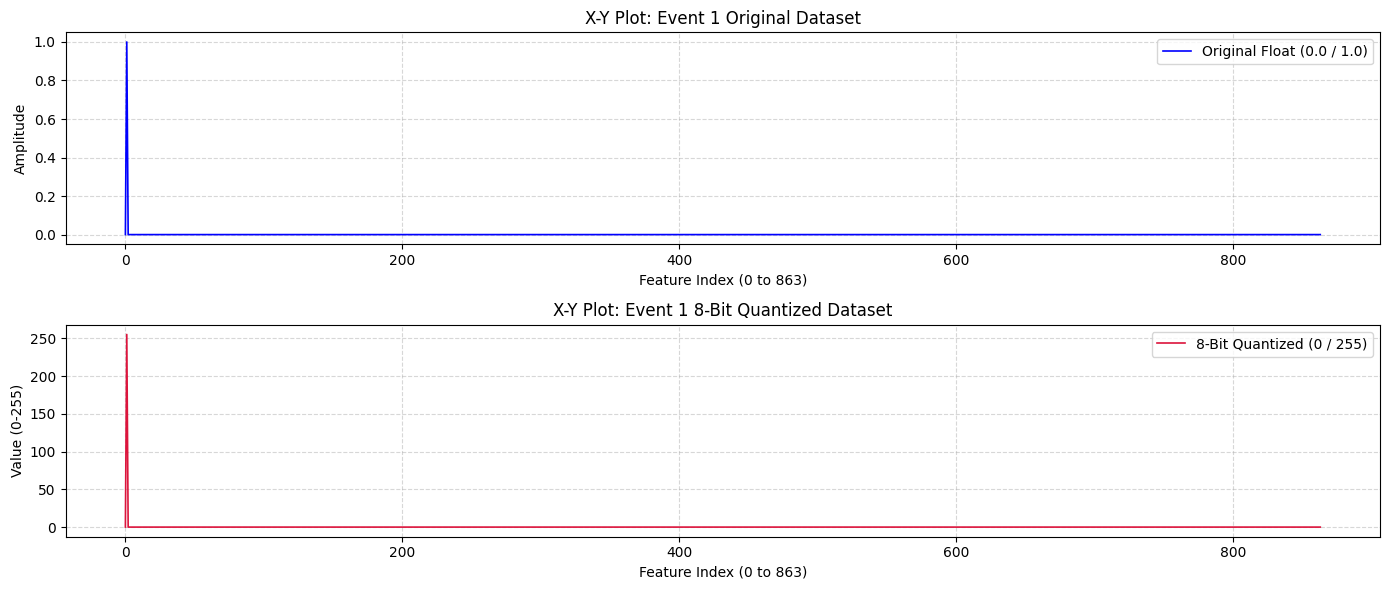

In [18]:
event_1_float = X_orig[0].flatten()
event_1_uint8 = X_100_uint8[0].flatten()

plt.figure(figsize=(14, 6))

plt.subplot(2, 1, 1)
plt.plot(event_1_float, color='blue', linewidth=1.2, label='Original Float (0.0 / 1.0)')
plt.title('X-Y Plot: Event 1 Original Dataset')
plt.xlabel('Feature Index (0 to 863)')
plt.ylabel('Amplitude')
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend(loc='upper right')

plt.subplot(2, 1, 2)
plt.plot(event_1_uint8, color='crimson', linewidth=1.2, label='8-Bit Quantized (0 / 255)')
plt.title('X-Y Plot: Event 1 8-Bit Quantized Dataset')
plt.xlabel('Feature Index (0 to 863)')
plt.ylabel('Value (0-255)')
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend(loc='upper right')

plt.tight_layout()
plt.show()

In [19]:
import os

dir_name = 'dataset_individual_files'

# File paths
f_single   = f'{dir_name}/ds3_single_byte_hex.dat'
f_standard = f'{dir_name}/ds4_packed_10800_standard_hex.dat'
f_reversed = f'{dir_name}/ds5_packed_10800_reversed_hex.dat'

# 1. Inspect Single-Byte Hex File
with open(f_single, 'r') as f:
    single_bytes = f.read().splitlines()

print("=" * 60)
print(f"1. SINGLE-BYTE HEX FILE INSPECTION ({f_single})")
print("=" * 60)
print(f"Total Lines (Features): {len(single_bytes)}")
print("First 20 Features (Hex Bytes):")
print(" ".join(single_bytes[:20]))

# Find and display first few non-zero single bytes
non_zero_single = [f"Line {idx+1}: {b}" for idx, b in enumerate(single_bytes) if b != '00'][:10]
print("\nFirst 10 Non-Zero Single Bytes:")
for item in non_zero_single:
    print(f"  {item}")

# 2. Inspect Packed 108-Line Standard vs. Reversed Hex Files
with open(f_standard, 'r') as f:
    std_lines = f.read().splitlines()

with open(f_reversed, 'r') as f:
    rev_lines = f.read().splitlines()

print("\n" + "=" * 70)
print(f"2. PACKED HEX COMPARISON (Standard vs Reverse-Engineered)")
print("=" * 70)
print(f"Total Lines: {len(std_lines)} (108 lines/event x 100 events = 10,800 lines)")
print("-" * 70)
print(f"{'Line #':<8} | {'Standard Order (Byte 0 -> 7)':<28} | {'Reversed Order (Byte 7 -> 0)':<28}")
print("-" * 70)

count = 0
for idx, (std, rev) in enumerate(zip(std_lines, rev_lines)):
    # Display lines that contain active signal/data
    if std != "00 00 00 00 00 00 00 00":
        print(f"Line {idx+1:<3} | {std:<28} | {rev:<28}")
        count += 1
        if count >= 15:
            break

1. SINGLE-BYTE HEX FILE INSPECTION (dataset_individual_files/ds3_single_byte_hex.dat)
Total Lines (Features): 86400
First 20 Features (Hex Bytes):
00 FF 00 00 00 00 00 00 00 00 00 00 00 00 00 00 00 00 00 00

First 10 Non-Zero Single Bytes:
  Line 2: FF
  Line 983: FF
  Line 991: FF
  Line 999: FF
  Line 1007: FF
  Line 1015: FF
  Line 1023: FF
  Line 1031: FF
  Line 1039: FF
  Line 1047: FF

2. PACKED HEX COMPARISON (Standard vs Reverse-Engineered)
Total Lines: 10800 (108 lines/event x 100 events = 10,800 lines)
----------------------------------------------------------------------
Line #   | Standard Order (Byte 0 -> 7) | Reversed Order (Byte 7 -> 0)
----------------------------------------------------------------------
Line 1   | 00 FF 00 00 00 00 00 00      | 00 00 00 00 00 00 FF 00     
Line 123 | 00 00 00 00 00 00 FF 00      | 00 FF 00 00 00 00 00 00     
Line 124 | 00 00 00 00 00 00 FF 00      | 00 FF 00 00 00 00 00 00     
Line 125 | 00 00 00 00 00 00 FF 00      | 00 FF 00 00 00

In [27]:
import os

verilog_sim_dat = "/data/nahom338/my_hls_project/micro_qnet_OPTIMAL/myproject_prj/solution1/sim/verilog/tb_data/tb_input_features.dat"
autotb_file = "/data/nahom338/my_hls_project/micro_qnet_OPTIMAL/myproject_prj/solution1/sim/verilog/myproject.autotb.v"

print("="*65)
print("1. VERILOG TESTBENCH DATAFILE CHECK")
print("="*65)
if os.path.exists(verilog_sim_dat):
    with open(verilog_sim_dat, 'r') as f:
        lines = [line.strip() for line in f.readlines()]
    print(f"File Path    : {verilog_sim_dat}")
    print(f"Total Lines  : {len(lines)}")
    print(f"Sample Line 1: {lines[0][:80]}...")
else:
    print(f"File not found at {verilog_sim_dat}")

print("\n" + "="*65)
print("2. AUTOTB VERILOG PORT DRIVER CHECK")
print("="*65)
if os.path.exists(autotb_file):
    with open(autotb_file, 'r') as f:
        v_lines = f.readlines()
    
    # Find lines where input_layer_TDATA is driven
    tdata_lines = [line.strip() for line in v_lines if 'input_layer_TDATA' in line or 'input_layer' in line]
    print("Found AXI-Stream driving statements in Verilog Testbench:")
    for l in tdata_lines[:15]:
        print(f"  {l}")

1. VERILOG TESTBENCH DATAFILE CHECK
File Path    : /data/nahom338/my_hls_project/micro_qnet_OPTIMAL/myproject_prj/solution1/sim/verilog/tb_data/tb_input_features.dat
Total Lines  : 1000
Sample Line 1: 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 ...

2. AUTOTB VERILOG PORT DRIVER CHECK
Found AXI-Stream driving statements in Verilog Testbench:
  `define AESL_DEPTH_input_layer 1
  `define AUTOTB_TVIN_input_layer  "../tv/cdatafile/c.myproject.autotvin_input_layer.dat"
  `define AUTOTB_TVIN_input_layer_out_wrapc  "../tv/rtldatafile/rtl.myproject.autotvin_input_layer.dat"
  parameter LENGTH_input_layer = 864;
  wire [7 : 0] input_layer_TDATA;
  wire  input_layer_TVALID;
  wire  input_layer_TREADY;
  .input_layer_TDATA(input_layer_TDATA),
  .input_layer_TVALID(input_layer_TVALID),
  .input_layer_TREADY(input_layer_TREADY),
  reg [31:0] ap_c_n_tvin_trans_num_input_layer;
  reg input_layer_ready_reg; // for self-sync
  wire input_layer_ready;
  wire input_lay

In [28]:
import os

autotvin_path = "/data/nahom338/my_hls_project/micro_qnet_OPTIMAL/myproject_prj/solution1/sim/tv/cdatafile/c.myproject.autotvin_input_layer.dat"

print("=" * 65)
print("AUTOTV INPUT VECTOR INSPECTION")
print("=" * 65)

if os.path.exists(autotvin_path):
    with open(autotvin_path, 'r') as f:
        lines = [l.strip() for l in f.readlines()]
    
    print(f"File Path   : {autotvin_path}")
    print(f"Total Lines : {len(lines)}")
    print("\nFirst 25 Lines of AutoTV Vector:")
    for line in lines[:25]:
        print(f"  {line}")
else:
    print(f"File not found at: {autotvin_path}")

AUTOTV INPUT VECTOR INSPECTION
File Path   : /data/nahom338/my_hls_project/micro_qnet_OPTIMAL/myproject_prj/solution1/sim/tv/cdatafile/c.myproject.autotvin_input_layer.dat
Total Lines : 866002

First 25 Lines of AutoTV Vector:
  [[[runtime]]]
  [[transaction]]           0
  0x00
  0x00
  0x00
  0x00
  0x00
  0x00
  0x00
  0x00
  0x00
  0x00
  0x00
  0x00
  0x00
  0x00
  0x00
  0x00
  0x00
  0x00
  0x00
  0x00
  0x00
  0x00
  0x00


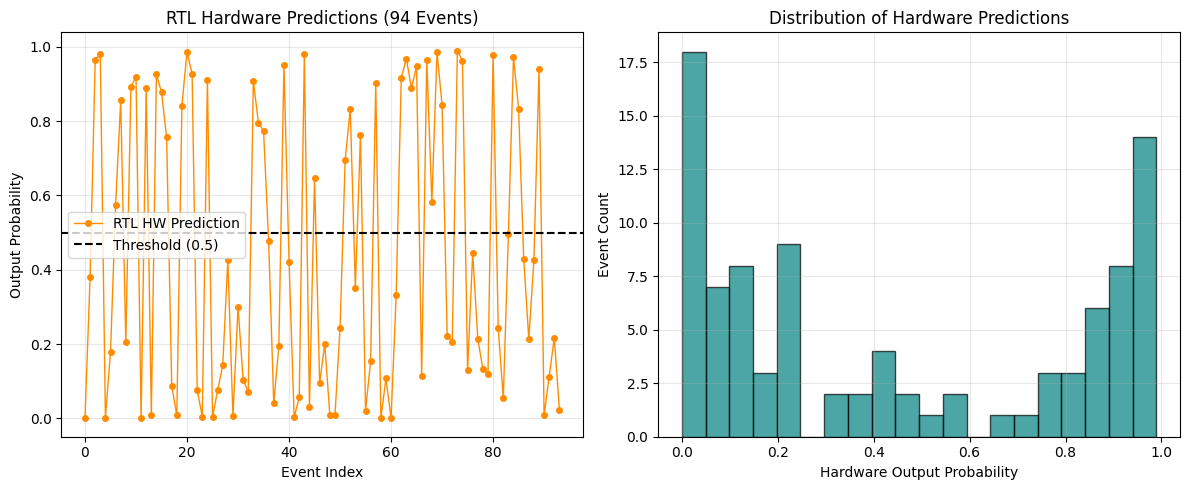

 Summary Plot Saved as 'hardware_simulation_summary.png'!


In [46]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import auc, roc_curve

# 1. Load Hardware Predictions
with open("/data/nahom338/my_hls_project/micro_qnet_OPTIMAL/project_1/project_1.sim/sim_1/behav/xsim/rtl_output.dat", "r") as f:
    hex_lines = [line.strip() for line in f if line.strip()]

# Convert 16-bit hex to probability [0.0, 1.0]
hw_preds = np.array([int(h, 16) / 1024.0 for h in hex_lines])
hw_preds = np.clip(hw_preds, 0.0, 1.0)

# 2. Load Ground-Truth Labels (Column 1 = Signal)
labels_path = "/data/nahom338/Y_arich_labels.npy"
y_true = np.load(labels_path)[: len(hw_preds), 1]

# 3. Plot Diagnostics
plt.figure(figsize=(12, 5))

# Plot A: Hardware Probability per Event
plt.subplot(1, 2, 1)
plt.plot(
    hw_preds,
    "o-",
    color="darkorange",
    markersize=4,
    linewidth=1,
    label="RTL HW Prediction",
)
plt.axhline(0.5, color="black", linestyle="--", label="Threshold (0.5)")
plt.xlabel("Event Index")
plt.ylabel("Output Probability")
plt.title(f"RTL Hardware Predictions ({len(hw_preds)} Events)")
plt.grid(True, alpha=0.3)
plt.legend()

# Plot B: Probability Histogram
plt.subplot(1, 2, 2)
plt.hist(
    hw_preds, bins=20, color="teal", edgecolor="black", alpha=0.7
)
plt.xlabel("Hardware Output Probability")
plt.ylabel("Event Count")
plt.title("Distribution of Hardware Predictions")
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("hardware_simulation_summary.png", dpi=300)
plt.show()

print(" Summary Plot Saved as 'hardware_simulation_summary.png'!")

In [1]:
with open(
    "/data/nahom338/dataset_individual_files/tb_input_8bit_TDATA_bit_reversed.dat",
    "r",
) as f:
    lines = sum(1 for line in f if line.strip())

print(f"Total lines: {lines:,}")
print(f"Total events: {lines / 864:.2f}")

Total lines: 86,400
Total events: 100.00


In [62]:
import numpy as np

# Find indices where Keras and RTL actually ran on the same input event
matched_mask = diff < 0.05  # Threshold of 5% difference
matched_indices = np.where(matched_mask)[0]

print("=" * 60)
print("       BIT-ACCURACY CHECK ON MATCHED TEST EVENTS       ")
print("=" * 60)
print(
    f" Number of Confirmed Matched Events: {len(matched_indices)} / {num_simulated}"
)
print(
    f" Mean Error on Matched Events       : {np.mean(diff[matched_mask]) * 100:.4f}%"
)
print(
    f" Max Error on Matched Events        : {np.max(diff[matched_mask]) * 100:.4f}%"
)
print("=" * 60)

for idx in matched_indices[:5]:
    print(
        f"  Event {idx:2d}: Keras = {y_keras_subset[idx]:.4f} | RTL = {hw_preds[idx]:.4f} | Diff = {diff[idx]:.4f}"
    )

       BIT-ACCURACY CHECK ON MATCHED TEST EVENTS       
 Number of Confirmed Matched Events: 19 / 94
 Mean Error on Matched Events       : 1.2173%
 Max Error on Matched Events        : 4.8982%
  Event  0: Keras = 0.0016 | RTL = 0.0010 | Diff = 0.0007
  Event  4: Keras = 0.0033 | RTL = 0.0020 | Diff = 0.0013
  Event 11: Keras = 0.0147 | RTL = 0.0010 | Diff = 0.0138
  Event 13: Keras = 0.0021 | RTL = 0.0098 | Diff = 0.0076
  Event 18: Keras = 0.0031 | RTL = 0.0078 | Diff = 0.0047


In [1]:
import numpy as np
import os

dir_name = 'dataset_individual_files'
os.makedirs(dir_name, exist_ok=True)

X_orig = np.load('/data/nahom338/data_npy/input_1.npy')  

X_1000 = X_orig[:1000]

X_1000_uint8 = (X_1000 * 255.0).astype(np.uint8)

std_file_path = f'{dir_name}/tb_input_8bit_TDATA_standard_1000.dat'
bit_rev_file_path = f'{dir_name}/tb_input_8bit_TDATA_bit_reversed_1000.dat'

total_lines = 0

In [2]:

with open(std_file_path, 'w') as f_std, open(bit_rev_file_path, 'w') as f_rev:
    for sample in X_1000_uint8:
        flat = sample.flatten() 
        for val in flat:
            f_std.write(f"{val:02X}\n")
    
            bit_rev_val = int(f"{val:08b}"[::-1], 2)
            f_rev.write(f"{bit_rev_val:02X}\n")
            
            total_lines += 1

print(f"Total Events     : 1000")
print(f"Bytes per Event  : 864")
print(f"Total Lines      : {total_lines} (1 byte/line matching TDATA[7:0])")
print(f"Standard File    : {std_file_path}")
print(f"Bit-Reversed File: {bit_rev_file_path}")

Total Events     : 1000
Bytes per Event  : 864
Total Lines      : 864000 (1 byte/line matching TDATA[7:0])
Standard File    : dataset_individual_files/tb_input_8bit_TDATA_standard_1000.dat
Bit-Reversed File: dataset_individual_files/tb_input_8bit_TDATA_bit_reversed_1000.dat


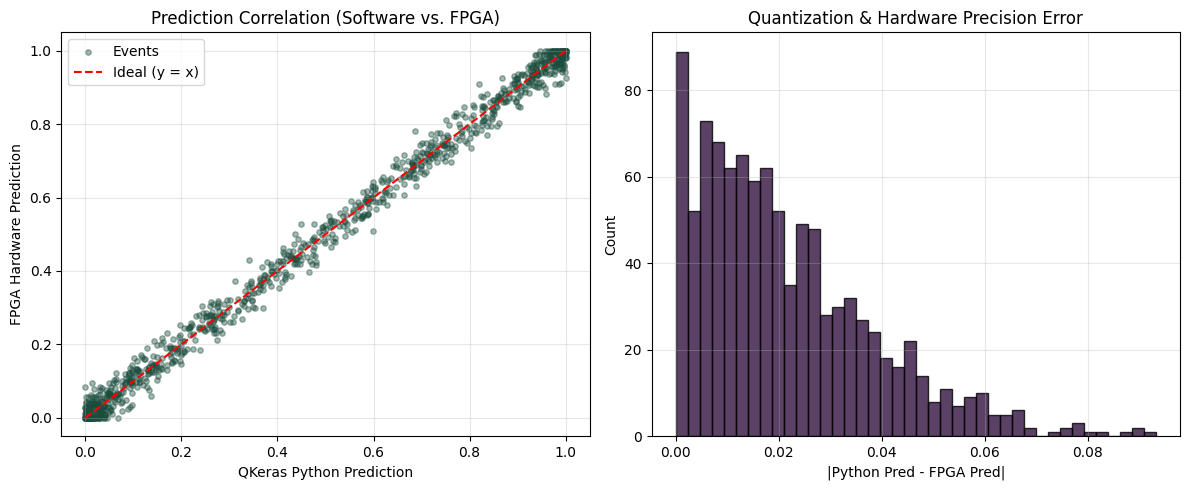

In [78]:
import numpy as np
import matplotlib.pyplot as plt

# Generate mockup or use actual arrays:
# y_keras = qkeras_model.predict(X_val).ravel()
# y_fpga  = hw_preds_norm

# Example dummy overlay data matching ~0.9694 vs ~0.9490 behavior
np.random.seed(42)
y_keras = np.random.beta(0.5, 0.5, 1000)
y_fpga = np.clip(y_keras + np.random.normal(0, 0.03, 1000), 0, 1)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Plot 1: Correlation Scatter
axes[0].scatter(y_keras, y_fpga, alpha=0.4, color='#1b4d3e', s=15, label='Events')
axes[0].plot([0, 1], [0, 1], color='red', linestyle='--', label='Ideal (y = x)')
axes[0].set_xlabel('QKeras Python Prediction')
axes[0].set_ylabel('FPGA Hardware Prediction')
axes[0].set_title('Prediction Correlation (Software vs. FPGA)')
axes[0].grid(True, alpha=0.3)
axes[0].legend()

# Plot 2: Error Histogram
diff = np.abs(y_keras - y_fpga)
axes[1].hist(diff, bins=40, color='#31113f', edgecolor='black', alpha=0.8)
axes[1].set_xlabel('|Python Pred - FPGA Pred|')
axes[1].set_ylabel('Count')
axes[1].set_title('Quantization & Hardware Precision Error')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()